In [10]:
import torch
import numpy as np
from torch import Tensor

from src.models import mk_model
from src.plotting import plt_sample
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig

In [4]:
x_train, y_train, x_test = load_preprocessed_dataset()

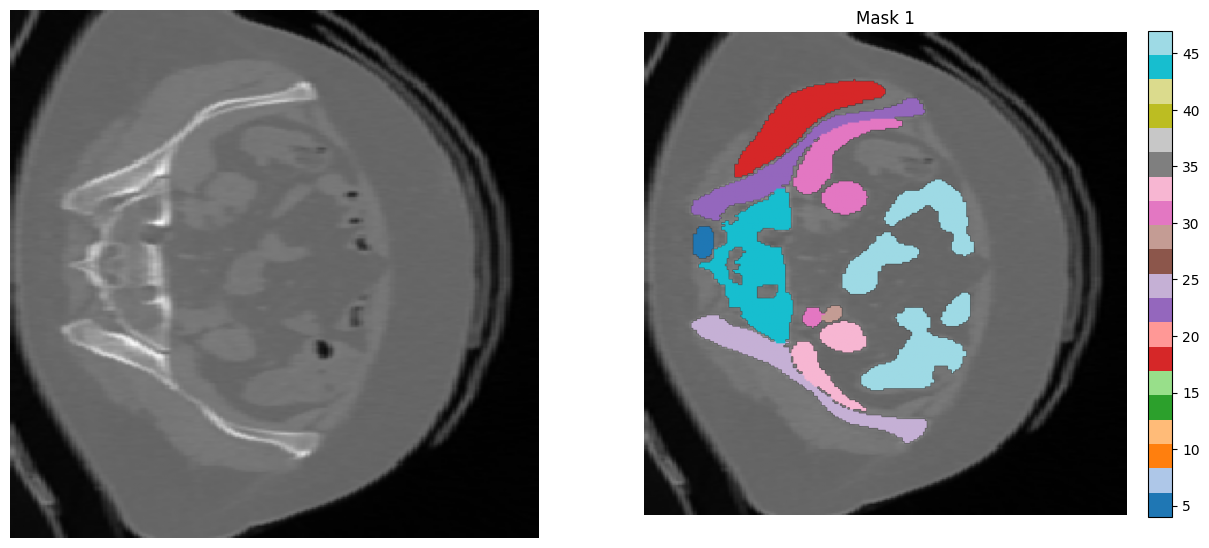

[ 0  4 18 23 24 28 30 31 32 44 47]


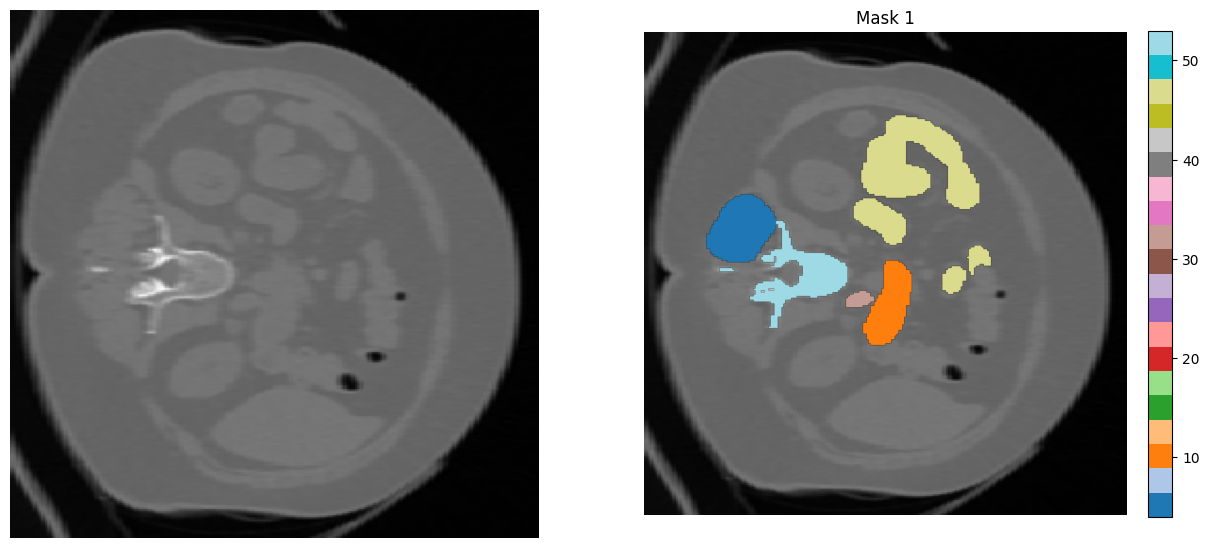

[ 0  4 10 33 47 53]


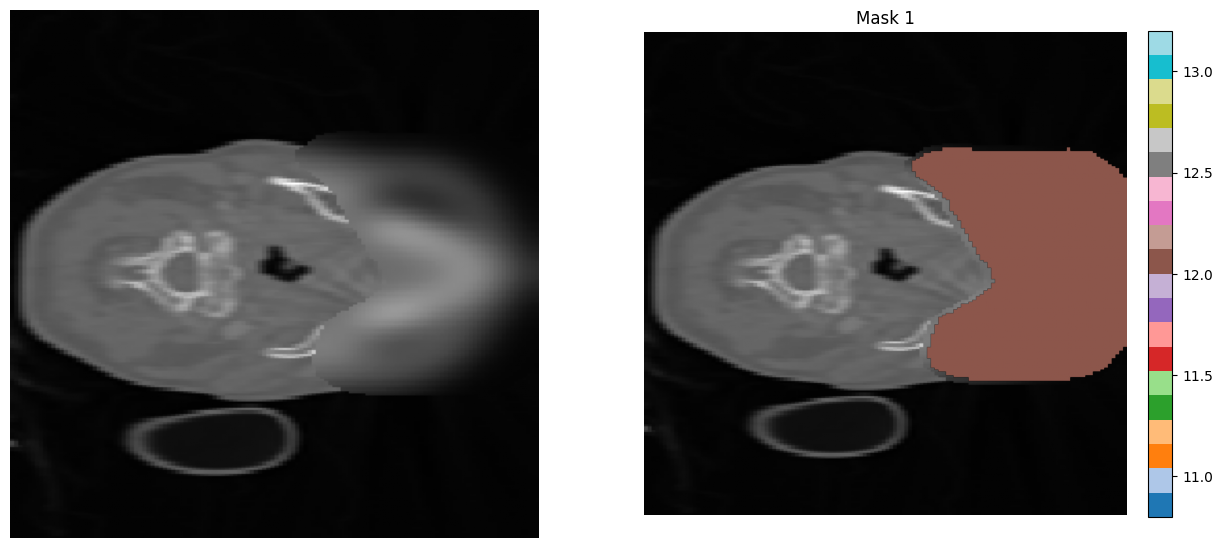

[ 0 12]


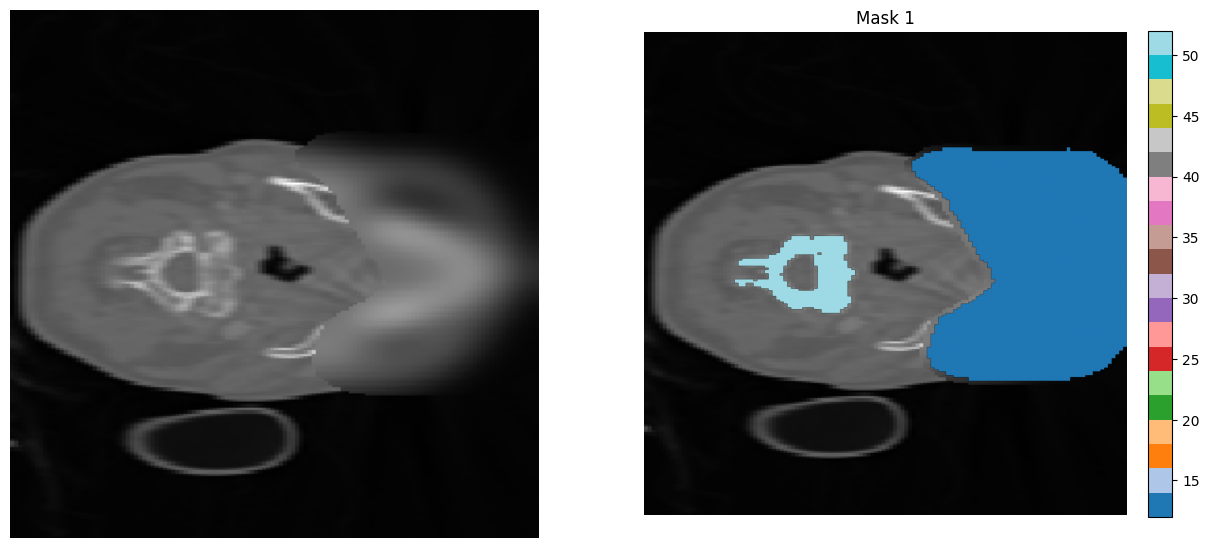

[ 0 12 52]


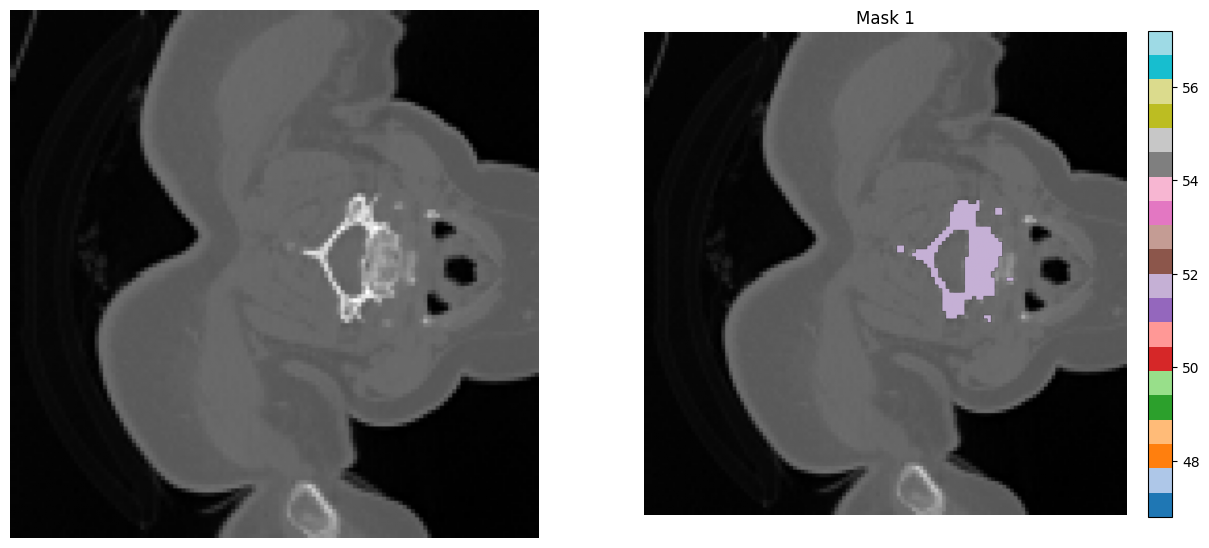

[ 0 52]


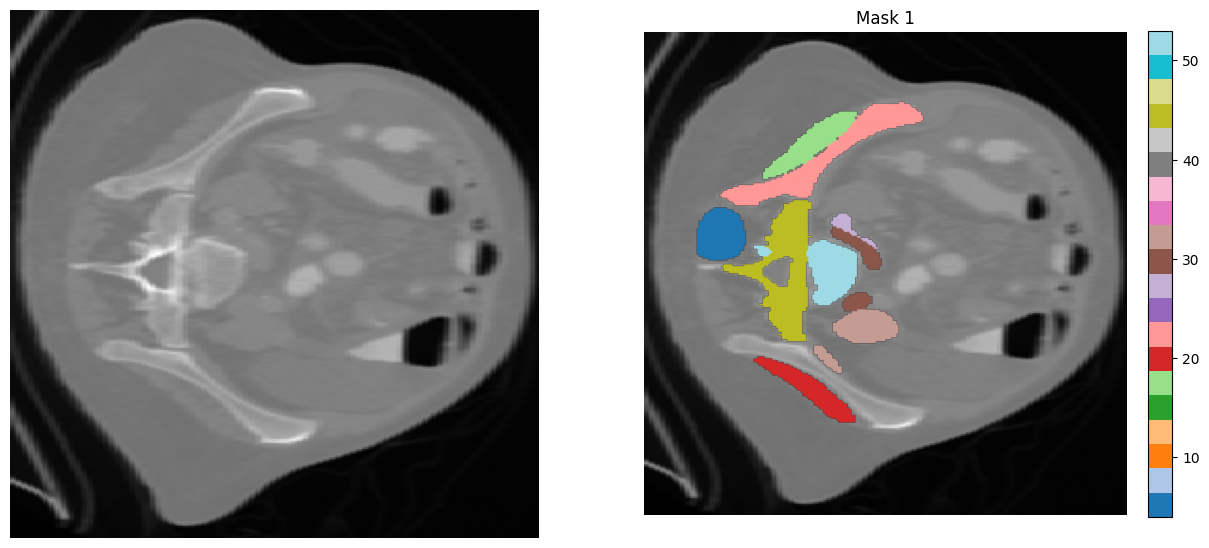

[ 0  4 18 19 23 27 29 30 32 44 53]


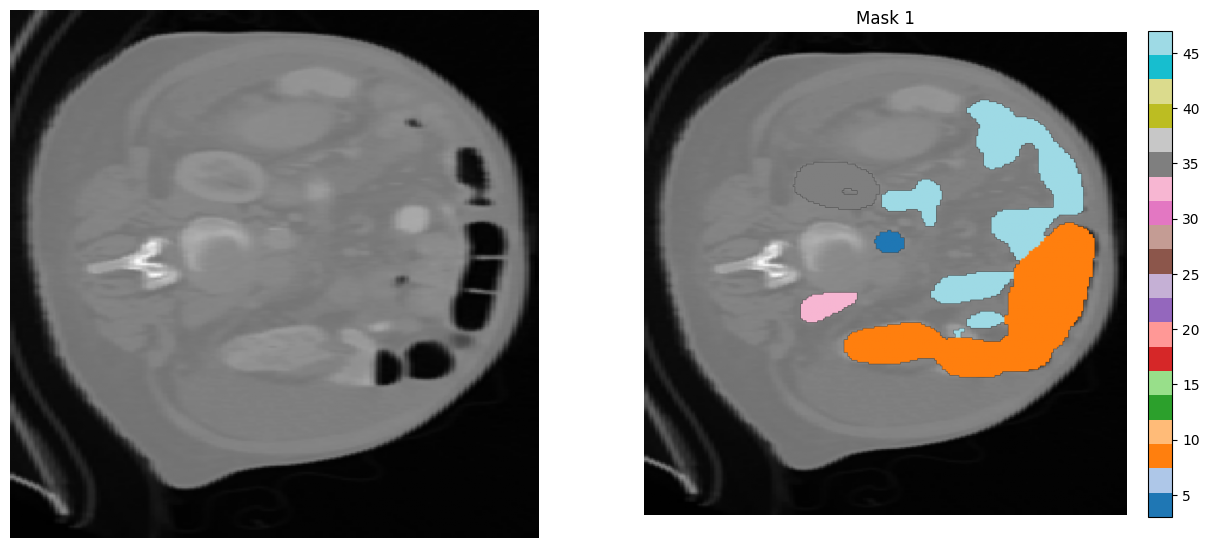

[ 0  3  9 32 34 47]


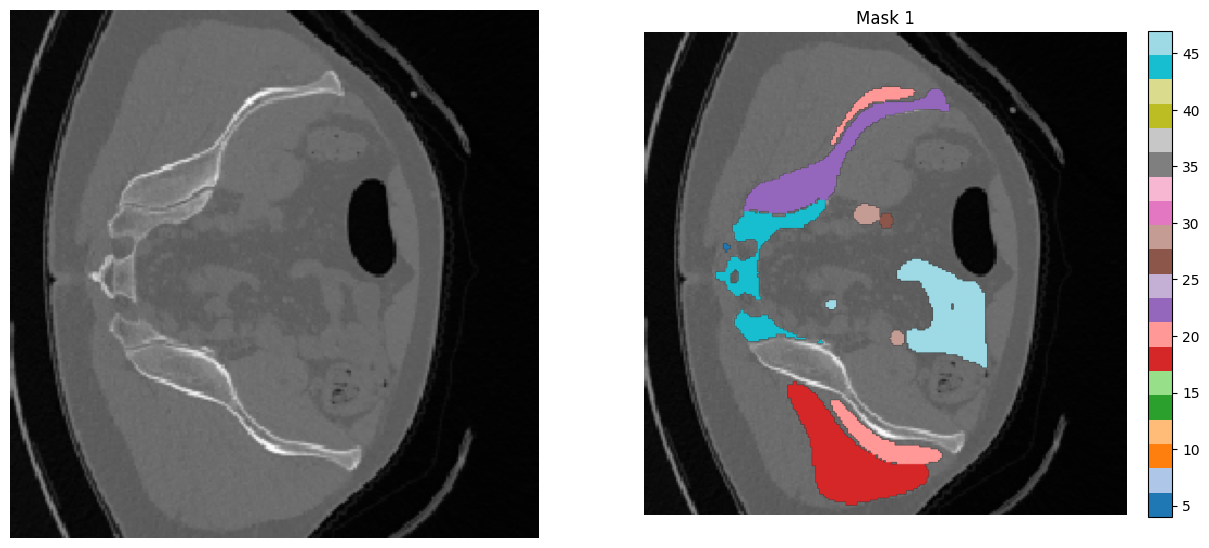

[ 0  4 19 20 21 23 27 28 29 44 47]


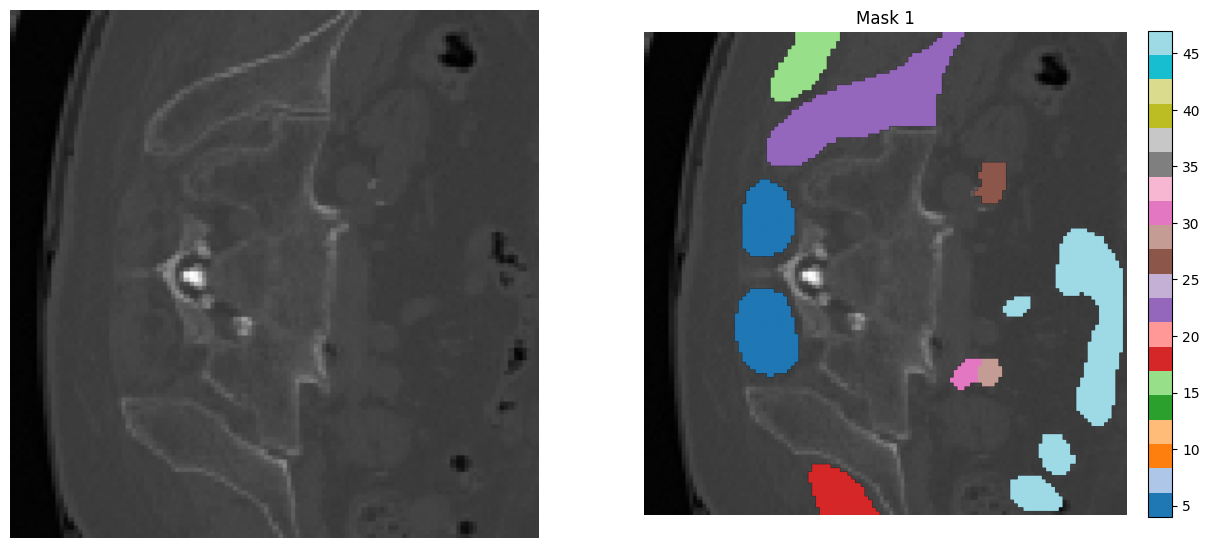

[ 0  4  5 16 19 23 27 28 30 47]


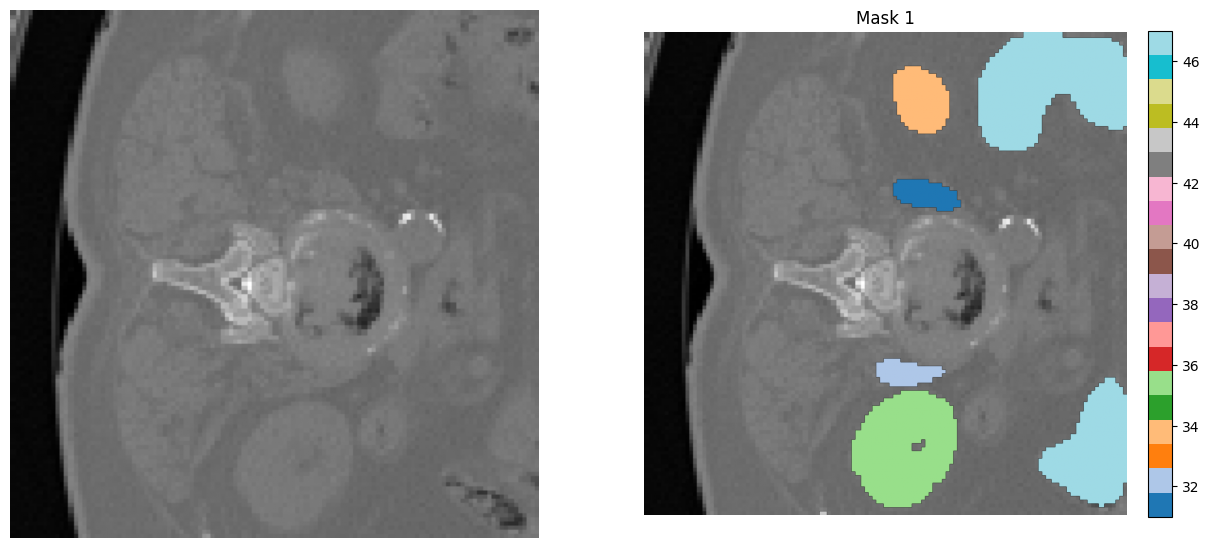

[ 0 31 32 34 35 43 47]


In [12]:
import matplotlib.pyplot as plt

def plt_sample(slice_image: Tensor, *seg_masks):
    fig, axes = plt.subplots(1, 1 + len(seg_masks), figsize=(15, 15))

    # Show base grayscale image
    axes[0].imshow(slice_image, cmap="gray")
    # axes[0].set_title("Image")
    axes[0].axis("off")

    # Display masks with their colormap + colorbar
    for seg_i, seg_mask in enumerate(seg_masks):
        ax = axes[seg_i + 1]
        ax.imshow(slice_image, cmap="gray")

        seg = seg_mask.reshape((256, 256))
        seg_masked = np.ma.masked_where(seg == 0, seg)

        im = ax.imshow(seg_masked, cmap="tab20")
        ax.set_title(f"Mask {seg_i + 1}")
        ax.axis("off")

        # Add colorbar for this mask
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

# TARGET_LABEL = 5
# has_label_mask = (y_train.reshape(-1, 256 * 256) == TARGET_LABEL).any(dim=1)
# x_with_label = x_train[has_label_mask][:, 0]
# y_with_label = y_train[has_label_mask]
# y_with_label[y_with_label != TARGET_LABEL] = 0
# PLT_SAMPLE_IDX = 0
N_SAMPLES_TO_PLOT = 10
for idx in range(N_SAMPLES_TO_PLOT):
    x_sample = x_train[idx, 0]
    y_sample = y_train[idx]
    plt_sample(x_sample, y_sample)
    print(np.unique(y_sample.cpu().numpy()))

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_cfg, model_cfg = TrainingConfig(), ModelConfig()
model = mk_model(train_cfg, model_cfg).to(device)
b_size = 10
x, y_true = x_train[:b_size], y_train[:b_size]
with torch.no_grad():
    y_pred = model(x.to(device))

In [ ]:
display(y_pred.shape)
display(torch.argmax(y_true.reshape(-1, 256 * 256), dim=1))

tensor([20122, 25670, 15774, 27726, 22950, 28253,  9394, 30862, 26850,   201])

In [4]:
from torch.nn.functional import one_hot

def match_pred_and_true(y_pred: Tensor, y_true: Tensor) -> tuple[Tensor, Tensor]:
    one_hot_pred = one_hot(y_pred.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(1)
    one_hot_true = one_hot(y_true.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(2)
    intersection = one_hot_true == one_hot_pred
    union = one_hot_pred[:, None] == one_hot_true[:, :, None]

match_pred_and_true(y_pred, y_true)

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 5 is not equal to len(dims) = 4